# QUBO Portfolio Optimization Results Analysis

This notebook loads and analyzes all QUBO results from the results/qubo folder, providing comprehensive comparisons across different solvers, datasets, and time periods.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import glob
import os
from pathlib import Path
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11

## Data Loading Functions

In [2]:
def load_pickle_result(file_path):
    """Load a single pickle result file."""
    try:
        with open(file_path, 'rb') as f:
            return pickle.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def parse_filename(filename):
    """Parse QUBO result filename to extract metadata."""
    # Expected format: results_{dataset}_{period}_{solver}.pkl
    basename = os.path.basename(filename)
    parts = basename.replace('.pkl', '').split('_')
    
    if len(parts) >= 4:
        dataset = parts[1]  # '10', '100', 'full', 'wide'
        period = int(parts[2])  # 0, 1, 2, ..., 9
        solver = parts[3]  # 'ew', 'ga', 'bf', 'hrp', 'dwave', etc.
        return dataset, period, solver
    return None, None, None

def load_all_results(results_dir='../../results/qubo'):
    """Load all QUBO results from the directory."""
    results = []
    
    # Find all pickle files
    pickle_files = glob.glob(os.path.join(results_dir, '*.pkl'))
    
    print(f"Found {len(pickle_files)} result files")
    
    for file_path in pickle_files:
        # Parse filename
        dataset, period, solver = parse_filename(file_path)
        
        if dataset is not None:
            # Load data
            data = load_pickle_result(file_path)
            
            if data is not None:
                # Extract key metrics
                portfolio_returns = data.get('portfolio_cumulative_returns', [])
                benchmark_returns = data.get('benchmark_cumulative_returns', [])
                execution_time = data.get('total_run_time', 0)
                start_date = data.get('start_date')
                end_date = data.get('end_date')
                
                # Calculate final return if available
                final_return = None
                if portfolio_returns is not None:
                    try:
                        if hasattr(portfolio_returns, '__len__') and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                    except:
                        pass
                
                # Calculate benchmark final return
                benchmark_final = None
                if benchmark_returns is not None:
                    try:
                        if hasattr(benchmark_returns, '__len__') and len(benchmark_returns) > 0:
                            benchmark_final = benchmark_returns[-1]
                    except:
                        pass
                
                results.append({
                    'filename': os.path.basename(file_path),
                    'dataset': dataset,
                    'period': period,
                    'solver': solver,
                    'portfolio_returns': portfolio_returns,
                    'benchmark_returns': benchmark_returns,
                    'final_return': final_return,
                    'benchmark_final': benchmark_final,
                    'execution_time': execution_time,
                    'start_date': start_date,
                    'end_date': end_date,
                    'data': data
                })
    
    return results

# Load all results
print("Loading all QUBO results...")
all_results = load_all_results()
print(f"Loaded {len(all_results)} successful results")

Loading all QUBO results...
Found 162 result files
Loaded 162 successful results


## Results Overview

In [3]:
# Create summary DataFrame
df_results = pd.DataFrame(all_results)

# Display overview
print("=" * 80)
print("QUBO PORTFOLIO OPTIMIZATION RESULTS OVERVIEW")
print("=" * 80)

print(f"\nTotal results loaded: {len(df_results)}")
print(f"\nDatasets: {sorted(df_results['dataset'].unique())}")
print(f"Solvers: {sorted(df_results['solver'].unique())}")
print(f"Periods: {sorted(df_results['period'].unique())}")

# Summary by dataset and solver
print("\nResults count by dataset and solver:")
summary_table = df_results.groupby(['dataset', 'solver']).size().unstack(fill_value=0)
print(summary_table)

# Map solver codes to readable names
solver_names = {
    'ew': 'Equal Weights',
    'ga': 'Genetic Algorithm',
    'bf': 'Scipy SLSQP',
    'hrp': 'Riskfolio QUBO',
    'dwave': 'D-Wave CQM',
    'cqm': 'D-Wave CQM',
    'quantum': 'D-Wave Quantum'
}

df_results['solver_name'] = df_results['solver'].map(lambda x: solver_names.get(x, x))

# Dataset info
dataset_info = {
    '10': '10 Stocks',
    '100': '100 Stocks', 
    'full': '439 Stocks (Full)',
    'wide': '680 Assets (Stocks + ETFs)'
}

df_results['dataset_name'] = df_results['dataset'].map(lambda x: dataset_info.get(x, x))

QUBO PORTFOLIO OPTIMIZATION RESULTS OVERVIEW

Total results loaded: 162

Datasets: ['10', '100', 'full', 'wide']
Solvers: ['bf', 'dwave', 'ew', 'ga', 'hrp']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Results count by dataset and solver:
solver   bf  dwave  ew  ga  hrp
dataset                        
10       10      0  10  10   10
100      10      0  10  10   10
full     10      1  10  10   10
wide     10      1  10  10   10


## 10 Stocks Results - Multiple Solver Comparison Across All Periods

This section creates a comprehensive comparison showing all solvers across all 10 periods for the 10-stock dataset.

In [4]:
# Filter for 10 stock results
df_10_stocks = df_results[df_results['dataset'] == '10'].copy()

print(f"Found {len(df_10_stocks)} results for 10 stocks dataset")
print(f"Solvers: {sorted(df_10_stocks['solver_name'].unique())}")
print(f"Periods: {sorted(df_10_stocks['period'].unique())}")

# Check data availability
valid_results = df_10_stocks[df_10_stocks['final_return'].notna()]
print(f"Results with valid portfolio returns: {len(valid_results)}")

Found 40 results for 10 stocks dataset
Solvers: ['Equal Weights', 'Genetic Algorithm', 'Riskfolio QUBO', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Results with valid portfolio returns: 40


Creating solver comparison plots for 10 stocks across all periods...


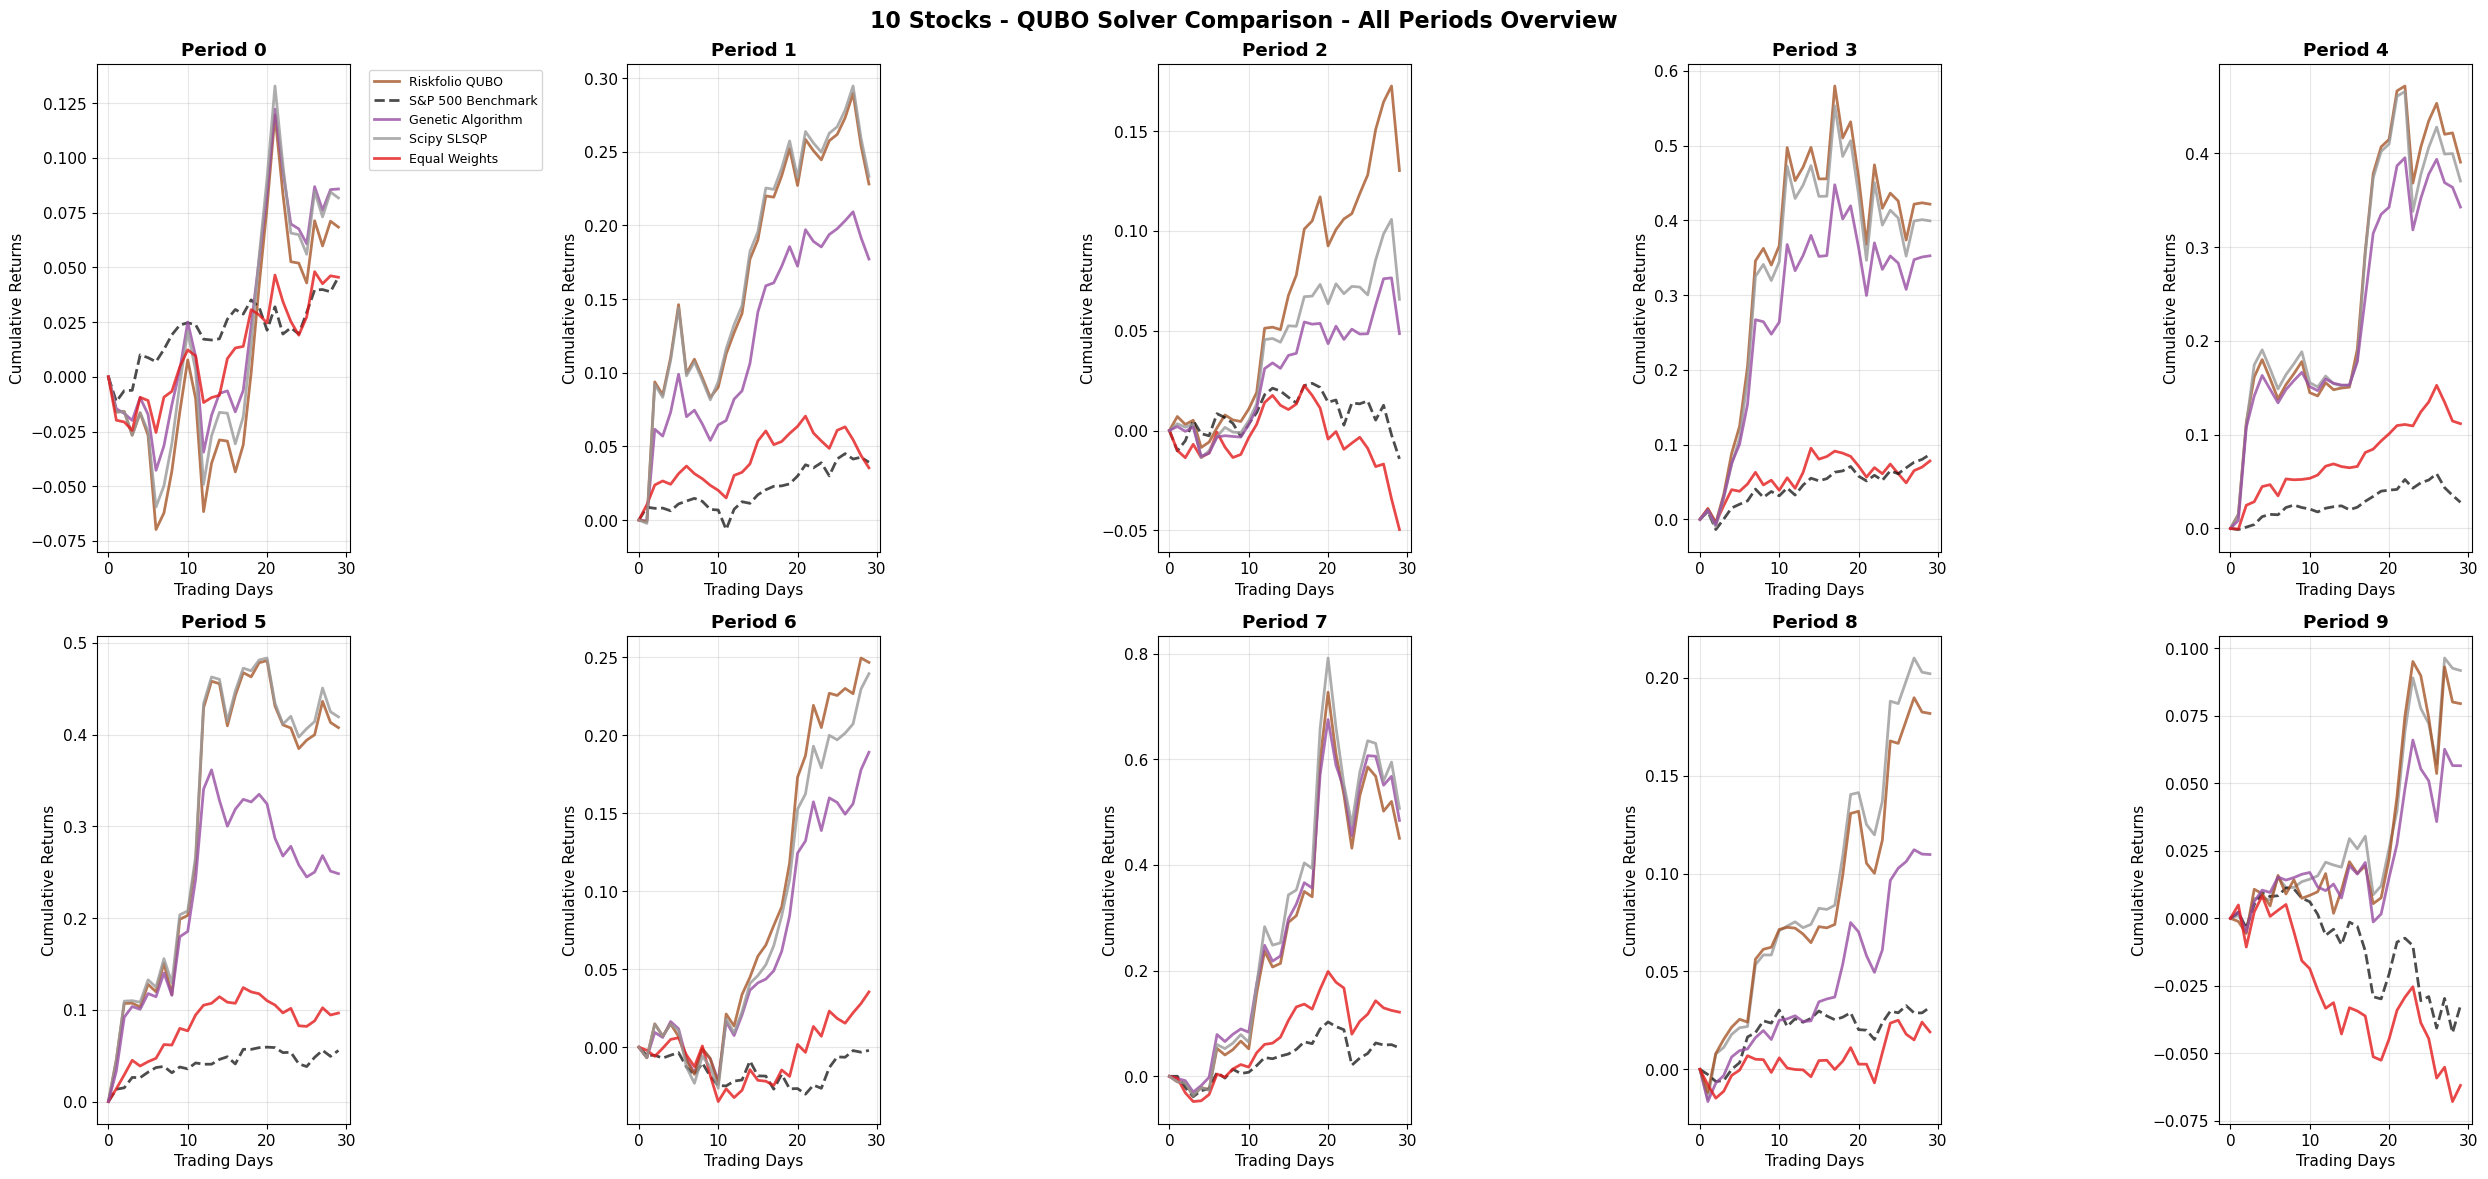

In [5]:
# Create the main comparison figure: Multiple plots showing solver comparisons for all 10 periods
def create_solver_comparison_plots(df_subset, title_prefix="QUBO Solver Comparison"):
    """Create a multi-plot figure showing solver comparisons across all periods."""
    
    periods = sorted(df_subset['period'].unique())
    n_periods = len(periods)
    
    # Create subplot grid (2 rows x 5 columns for 10 periods)
    fig, axes = plt.subplots(2, 5, figsize=(25, 12))
    fig.suptitle(f'{title_prefix} - All Periods Overview', fontsize=16, fontweight='bold')
    
    # Color palette for solvers
    solvers = sorted(df_subset['solver_name'].unique())
    colors = plt.cm.Set1(np.linspace(0, 1, len(solvers)))
    solver_colors = dict(zip(solvers, colors))
    
    # Plot each period
    for idx, period in enumerate(periods):
        row = idx // 5
        col = idx % 5
        ax = axes[row, col]
        
        period_data = df_subset[df_subset['period'] == period]
        
        # Plot portfolio returns for each solver in this period
        legend_added = False
        benchmark_plotted = False
        
        for _, result in period_data.iterrows():
            if result['portfolio_returns'] is not None:
                try:
                    portfolio_data = result['portfolio_returns']
                    if hasattr(portfolio_data, '__len__') and len(portfolio_data) > 0:
                        color = solver_colors.get(result['solver_name'], 'gray')
                        ax.plot(portfolio_data, 
                               label=result['solver_name'], 
                               color=color, 
                               linewidth=2, 
                               alpha=0.8)
                        
                        # Plot benchmark (only once per subplot)
                        if not benchmark_plotted and result['benchmark_returns'] is not None:
                            try:
                                benchmark_data = result['benchmark_returns']
                                if hasattr(benchmark_data, '__len__') and len(benchmark_data) > 0:
                                    ax.plot(benchmark_data, 
                                           label='S&P 500 Benchmark', 
                                           color='black', 
                                           linestyle='--', 
                                           linewidth=2, 
                                           alpha=0.7)
                                    benchmark_plotted = True
                            except:
                                pass
                                
                except Exception as e:
                    print(f"Error plotting period {period}, solver {result['solver_name']}: {e}")
        
        ax.set_title(f'Period {period}', fontweight='bold')
        ax.set_xlabel('Trading Days')
        ax.set_ylabel('Cumulative Returns')
        ax.grid(True, alpha=0.3)
        
        # Only add legend to first subplot
        if idx == 0:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    
    plt.tight_layout()
    return fig

# Create the main comparison plot for 10 stocks
if len(df_10_stocks) > 0:
    print("Creating solver comparison plots for 10 stocks across all periods...")
    fig_10_stocks = create_solver_comparison_plots(df_10_stocks, "10 Stocks - QUBO Solver Comparison")
    plt.show()
else:
    print("No data available for 10 stocks comparison")

## Performance Summary for 10 Stocks

In [6]:
# Performance analysis for 10 stocks
def analyze_performance(df_subset, dataset_name=""):
    """Analyze performance metrics for a dataset subset."""
    
    valid_results = df_subset[df_subset['final_return'].notna()].copy()
    
    if len(valid_results) == 0:
        print(f"No valid results for {dataset_name}")
        return None
    
    # Group by solver and calculate statistics
    performance_stats = []
    
    for solver in valid_results['solver_name'].unique():
        solver_data = valid_results[valid_results['solver_name'] == solver]
        
        returns = solver_data['final_return'].values
        times = solver_data['execution_time'].values
        
        stats = {
            'Solver': solver,
            'Periods': len(solver_data),
            'Avg_Return': np.mean(returns),
            'Std_Return': np.std(returns),
            'Min_Return': np.min(returns),
            'Max_Return': np.max(returns),
            'Avg_Time': np.mean(times),
            'Std_Time': np.std(times),
            'Success_Rate': len(solver_data) / len(df_subset[df_subset['solver_name'] == solver]) * 100
        }
        performance_stats.append(stats)
    
    df_stats = pd.DataFrame(performance_stats)
    df_stats = df_stats.round(4)
    
    return df_stats

# Analyze 10 stocks performance
print("=" * 80)
print("10 STOCKS - PERFORMANCE ANALYSIS")
print("=" * 80)

stats_10 = analyze_performance(df_10_stocks, "10 Stocks")
if stats_10 is not None:
    # Sort by average return
    stats_10_sorted = stats_10.sort_values('Avg_Return', ascending=False)
    print(stats_10_sorted.to_string(index=False))
    
    print(f"\nBest performer: {stats_10_sorted.iloc[0]['Solver']} (avg return: {stats_10_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest solver: {stats_10.loc[stats_10['Avg_Time'].idxmin(), 'Solver']} ({stats_10['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {stats_10.loc[stats_10['Success_Rate'].idxmax(), 'Solver']} ({stats_10['Success_Rate'].max():.1f}%)")

10 STOCKS - PERFORMANCE ANALYSIS
           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return  Avg_Time  Std_Time  Success_Rate
      Scipy SLSQP       10      0.2610      0.1484      0.0657      0.5069    1.9041    0.2344         100.0
   Riskfolio QUBO       10      0.2605      0.1395      0.0684      0.4504    0.5165    0.0470         100.0
Genetic Algorithm       10      0.2095      0.1383      0.0486      0.4842   73.9227    0.2424         100.0
    Equal Weights       10      0.0432      0.0594     -0.0619      0.1215    0.0838    0.0308         100.0

Best performer: Scipy SLSQP (avg return: 0.2610)
Fastest solver: Equal Weights (0.08s)
Most reliable: Scipy SLSQP (100.0%)


## Summary Statistics and Performance Metrics

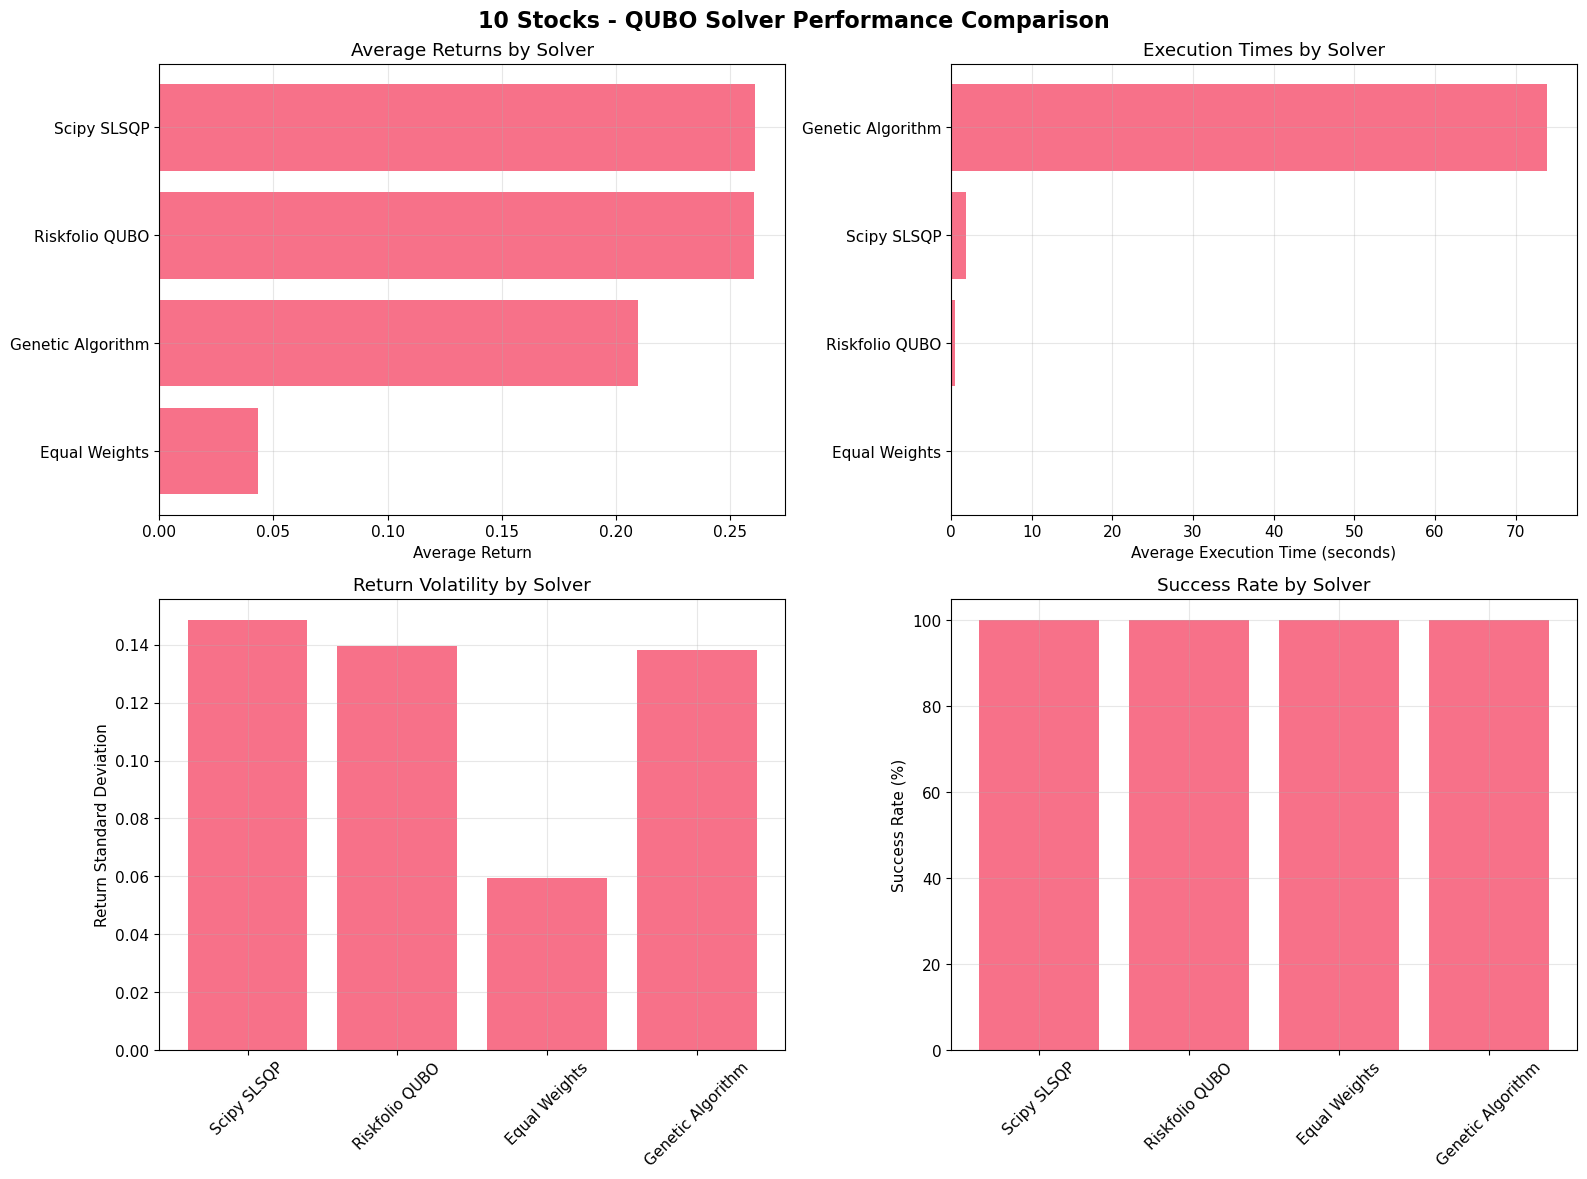

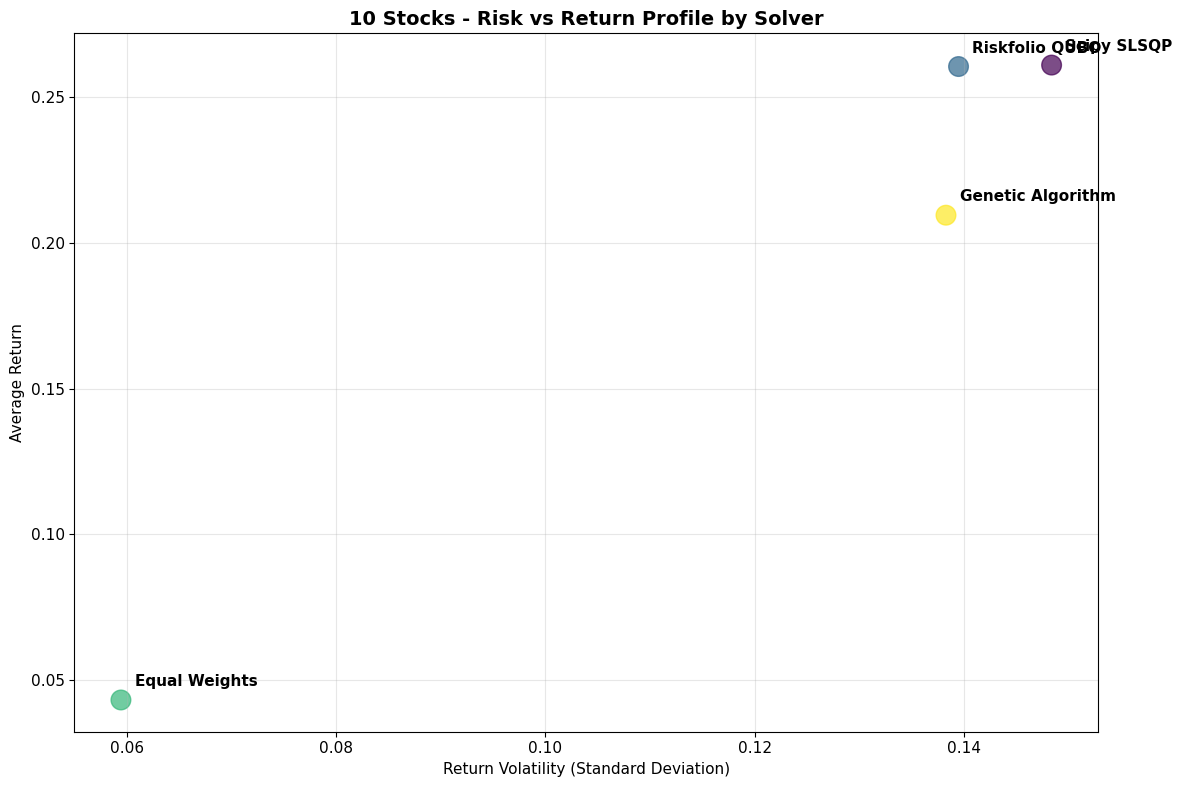

In [7]:
# Create performance comparison plots
if stats_10 is not None and len(stats_10) > 0:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('10 Stocks - QUBO Solver Performance Comparison', fontsize=16, fontweight='bold')
    
    # 1. Average Returns
    stats_10_sorted = stats_10.sort_values('Avg_Return', ascending=True)
    ax1.barh(stats_10_sorted['Solver'], stats_10_sorted['Avg_Return'])
    ax1.set_xlabel('Average Return')
    ax1.set_title('Average Returns by Solver')
    ax1.grid(True, alpha=0.3)
    
    # 2. Execution Times
    stats_10_time = stats_10.sort_values('Avg_Time', ascending=True)
    ax2.barh(stats_10_time['Solver'], stats_10_time['Avg_Time'])
    ax2.set_xlabel('Average Execution Time (seconds)')
    ax2.set_title('Execution Times by Solver')
    ax2.grid(True, alpha=0.3)
    
    # 3. Return Volatility
    ax3.bar(stats_10['Solver'], stats_10['Std_Return'])
    ax3.set_ylabel('Return Standard Deviation')
    ax3.set_title('Return Volatility by Solver')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)
    
    # 4. Success Rate
    ax4.bar(stats_10['Solver'], stats_10['Success_Rate'])
    ax4.set_ylabel('Success Rate (%)')
    ax4.set_title('Success Rate by Solver')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.show()

    # Risk-Return scatter plot
    plt.figure(figsize=(12, 8))
    plt.scatter(stats_10['Std_Return'], stats_10['Avg_Return'], 
                s=200, alpha=0.7, c=range(len(stats_10)), cmap='viridis')
    
    for i, row in stats_10.iterrows():
        plt.annotate(row['Solver'], 
                    (row['Std_Return'], row['Avg_Return']),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=11, fontweight='bold')
    
    plt.xlabel('Return Volatility (Standard Deviation)')
    plt.ylabel('Average Return')
    plt.title('10 Stocks - Risk vs Return Profile by Solver', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Extended Analysis - All Datasets Overview

In [8]:
# Overview of all datasets
print("=" * 100)
print("COMPREHENSIVE OVERVIEW - ALL DATASETS AND SOLVERS")
print("=" * 100)

for dataset in sorted(df_results['dataset'].unique()):
    dataset_data = df_results[df_results['dataset'] == dataset]
    dataset_name = dataset_info.get(dataset, dataset)
    
    print(f"\n{dataset_name}:")
    print("-" * 50)
    
    stats = analyze_performance(dataset_data, dataset_name)
    if stats is not None:
        stats_sorted = stats.sort_values('Avg_Return', ascending=False)
        for _, row in stats_sorted.iterrows():
            print(f"{row['Solver']:<20}: Return={row['Avg_Return']:>8.4f}, Time={row['Avg_Time']:>8.2f}s, Success={row['Success_Rate']:>6.1f}%")
    else:
        print("  No valid results found")

# Create dataset comparison
dataset_comparison = []
for dataset in sorted(df_results['dataset'].unique()):
    dataset_data = df_results[df_results['dataset'] == dataset]
    valid_data = dataset_data[dataset_data['final_return'].notna()]
    
    if len(valid_data) > 0:
        dataset_comparison.append({
            'Dataset': dataset_info.get(dataset, dataset),
            'Total_Results': len(dataset_data),
            'Valid_Results': len(valid_data),
            'Avg_Return': valid_data['final_return'].mean(),
            'Avg_Execution_Time': valid_data['execution_time'].mean(),
            'Success_Rate': len(valid_data) / len(dataset_data) * 100
        })

if dataset_comparison:
    df_comparison = pd.DataFrame(dataset_comparison)
    print("\n" + "=" * 80)
    print("DATASET COMPARISON SUMMARY")
    print("=" * 80)
    print(df_comparison.round(4).to_string(index=False))

COMPREHENSIVE OVERVIEW - ALL DATASETS AND SOLVERS

10 Stocks:
--------------------------------------------------
Scipy SLSQP         : Return=  0.2610, Time=    1.90s, Success= 100.0%
Riskfolio QUBO      : Return=  0.2605, Time=    0.52s, Success= 100.0%
Genetic Algorithm   : Return=  0.2095, Time=   73.92s, Success= 100.0%
Equal Weights       : Return=  0.0432, Time=    0.08s, Success= 100.0%

100 Stocks:
--------------------------------------------------
Riskfolio QUBO      : Return=  0.3198, Time=    2.53s, Success= 100.0%
Scipy SLSQP         : Return=  0.2953, Time=   45.83s, Success= 100.0%
Genetic Algorithm   : Return=  0.1264, Time=  166.42s, Success= 100.0%
Equal Weights       : Return=  0.0361, Time=    0.07s, Success= 100.0%

439 Stocks (Full):
--------------------------------------------------
Riskfolio QUBO      : Return=  0.3263, Time=   32.86s, Success= 100.0%
Scipy SLSQP         : Return=  0.2194, Time= 1737.85s, Success= 100.0%
Genetic Algorithm   : Return=  0.0776, Tim